# Bank Customer Churn Prediction: Identifying Flight Risk
**Author:** Tuyet Pham  
**Date:** March 2026

**Project Objective:** This notebook builds an end-to-end machine learning pipeline to identify retail banking customers with a high probability of churning. By handling a severe 79/21 class imbalance, we optimized a Random Forest classifier to prioritize actionable retention interventions, extracting key feature importances to inform the business strategy.
---

In [1]:
## 1. Setup and Data Ingestion
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
## Import data
df = pd.read_csv("Churn_Modelling.csv", delimiter=',')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [3]:
## explore data
df.head()
df.isnull().sum() # no missing value

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
## values frequency
df['Geography'].value_counts()
df['Gender'].value_counts()
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

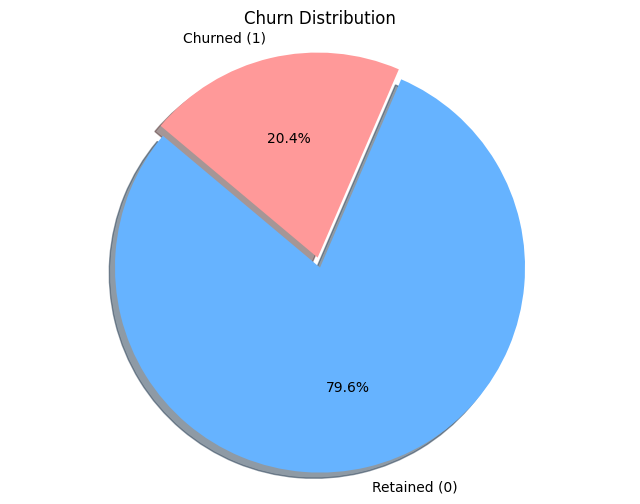

In [5]:
## 2. Exploratory Data Analysis (EDA)
churn_counts = df['Exited'].value_counts() # imbalanced data where 80% customers are retained

### 2.1 Demographic Insights
labels = ['Retained (0)', 'Churned (1)']
colors = ['#66b3ff', '#ff9999'] # Light blue and light red
explode = (0.05, 0)             # Slightly separates the first slice for aesthetics

#### Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(churn_counts, 
        labels=labels, 
        colors=colors, 
        autopct='%1.1f%%',      # Displays the percentage with 1 decimal place
        startangle=140,         # Rotates the pie chart for a better starting angle
        explode=explode,
        shadow=True)

plt.title('Churn Distribution')
plt.axis('equal')               # Ensures the pie chart is a perfect circle

#### Display the chart
plt.show()

<Axes: xlabel='Exited', ylabel='CreditScore'>

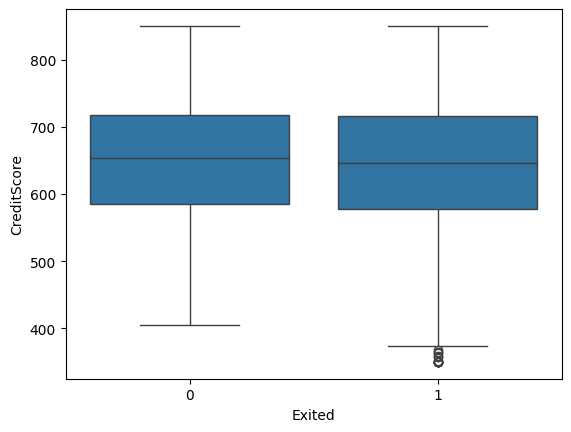

In [6]:
#### boxplot of CreditScore vs Exited 
sns.boxplot(x="Exited", y="CreditScore", data=df)

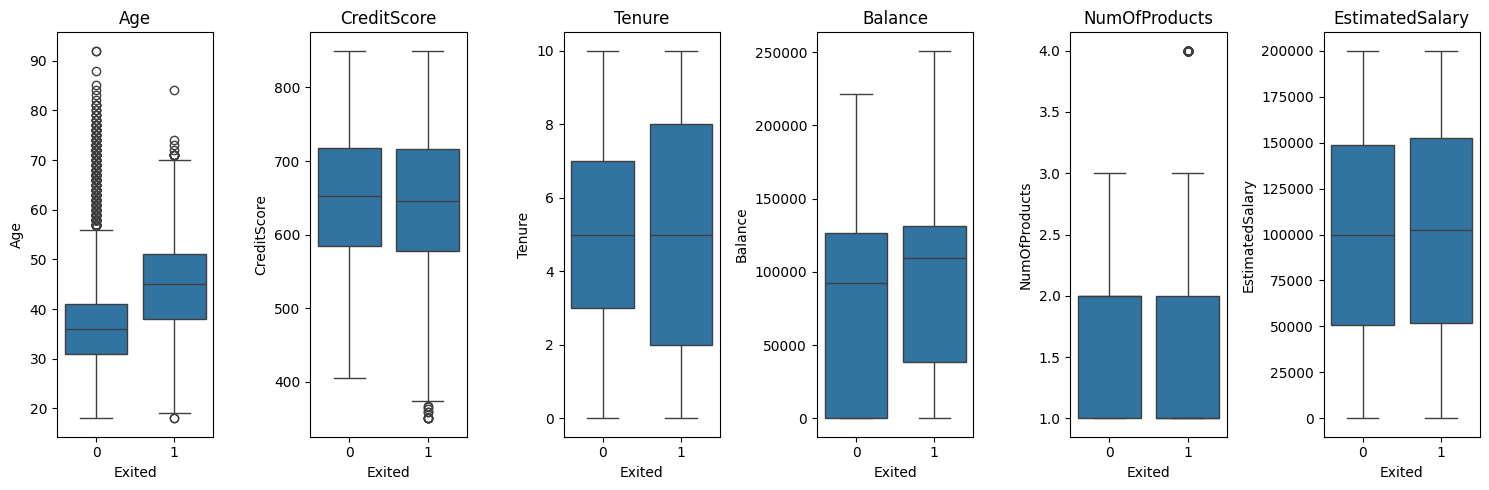

In [7]:
#### boxplot between numerical variables vs target variable 

num_cols = ['Age', 'CreditScore', 'Tenure', 'Balance','NumOfProducts','EstimatedSalary']
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    temp = pd.DataFrame({
        col: df[col],
        'Exited': df['Exited']
    })
    sns.boxplot(data=temp, x='Exited', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()
# There is no difference between churned and retained customers in CreditScore, NumOfProducts, EstimatedSalary
# The midle-aged people tend to churn than the younger ones.
# With regard to the tenure, the clients on either extreme end (spent little time with the bank or a lot of time with the bank) 
# are more likely to churn compared to those that are of average tenure.

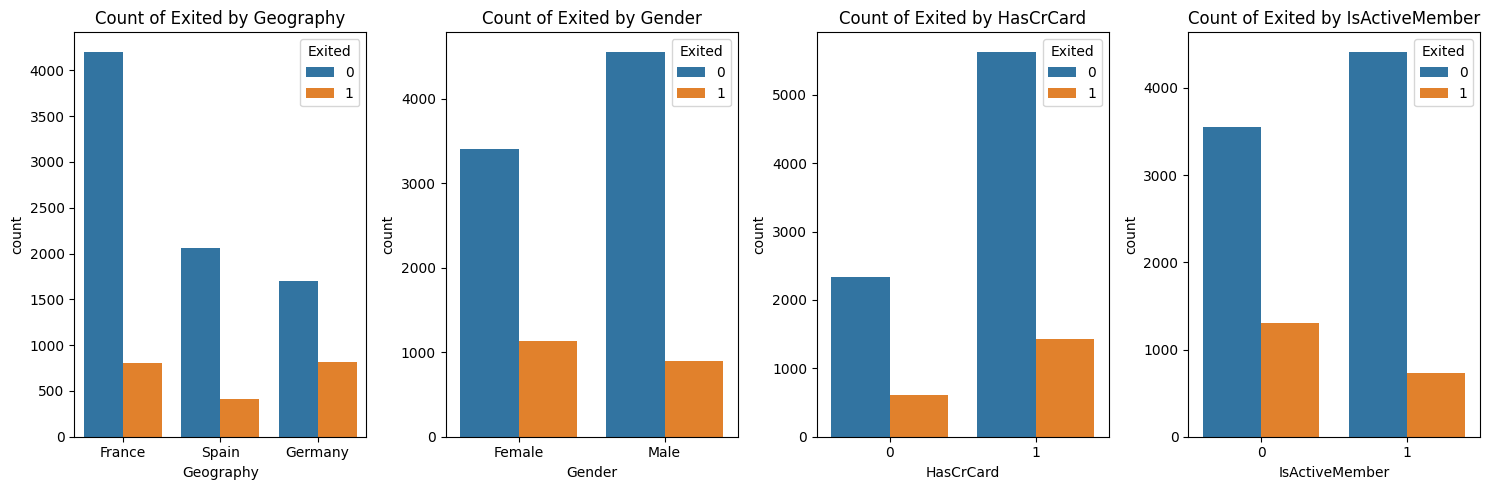

In [8]:
#### bar plot for category variables
cat_cols = ['Geography','Gender','HasCrCard','IsActiveMember']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(15, 5))

for ax, col in zip(axes, cat_cols):
    
    sns.countplot(x=col, hue='Exited', data=df, ax=ax)
    ax.set_title(f'Count of Exited by {col}')
    ax.legend(title='Exited', loc='upper right')

#### Show the plot
plt.tight_layout()
plt.show()

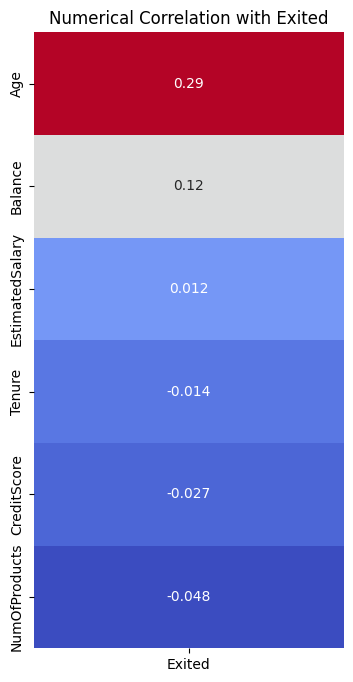

In [9]:
### Correlation Map
#### Identify numerical columns (exclude the target itself)
num_cols = ['Age', 'CreditScore', 'Tenure', 'Balance','NumOfProducts','EstimatedSalary']

##### Calculate correlation of all numbers with 'Exited'
correlations = df[num_cols + ['Exited']].corr()['Exited'].drop('Exited').sort_values(ascending=False)

#### Visualize with a Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 8))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Numerical Correlation with Exited')
plt.show()

In [10]:
### Chi-square test whether each categorical variable has a statistically significant relationship with customer churn
from scipy.stats import chi2_contingency

cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
chi2_results = {}

for col in cat_cols:
    # Create a cross-tabulation table
    contingency_table = pd.crosstab(df[col], df['Exited'])
    
    # Run the test
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    chi2_results[col] = p

# Display results
for col, p_val in chi2_results.items():
    status = "Significant" if p_val < 0.05 else "Not Significant"
    print(f"{col}: p-value = {p_val:.4f} ({status})")
#### Results: Geography, Gender, IsActiveMember have statistically significant relationship with Existed

Geography: p-value = 0.0000 (Significant)
Gender: p-value = 0.0000 (Significant)
HasCrCard: p-value = 0.4924 (Not Significant)
IsActiveMember: p-value = 0.0000 (Significant)


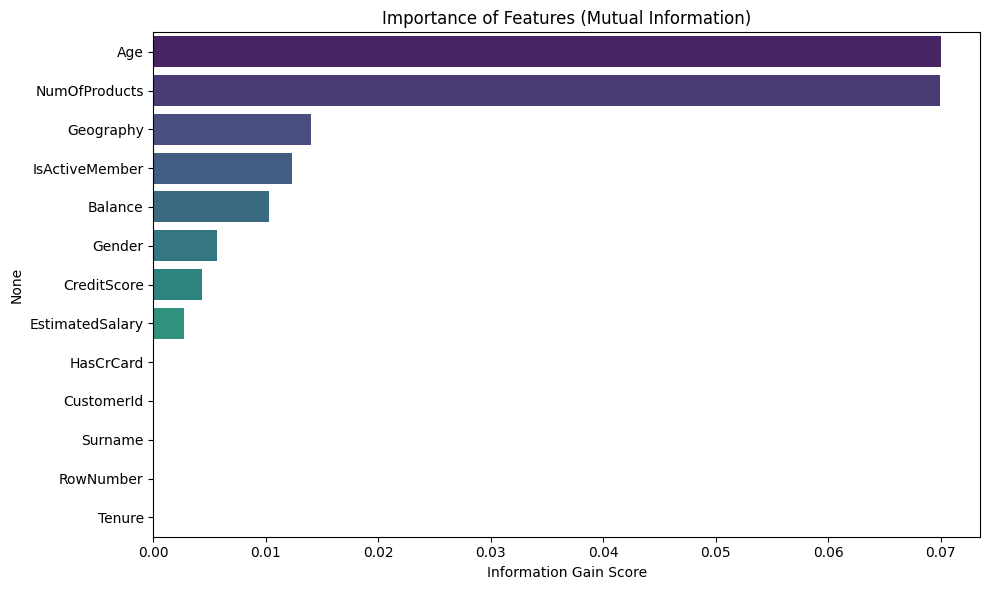

Age                0.069996
NumOfProducts      0.069953
Geography          0.014017
IsActiveMember     0.012291
Balance            0.010234
Gender             0.005652
CreditScore        0.004319
EstimatedSalary    0.002704
HasCrCard          0.000025
CustomerId         0.000000
Surname            0.000000
RowNumber          0.000000
Tenure             0.000000
Name: MI Scores, dtype: float64


In [11]:
### a general test catches non-linear patterns that correlation would miss.
from sklearn.feature_selection import mutual_info_classif

#### 1. Prepare Features (X) and Target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

##### Identify categorical features for encoding
cat_features = X.select_dtypes(include=['object', 'category']).columns

##### Convert categories to codes (MI algorithm requires numbers)
X_encoded = X.copy()
for col in cat_features:
    X_encoded[col] = X_encoded[col].astype('category').cat.codes

#### 2. Tell the algorithm which features are discrete (categories/binary)
##### This improves the accuracy of the Information Gain calculation
discrete_features = [True if (X[col].dtype == 'object' or X[col].nunique() < 10) 
                     else False for col in X.columns]

#### 3. Calculate scores
mi_scores = mutual_info_classif(X_encoded, y, discrete_features=discrete_features, random_state=42)

#### 4. Link names and scores in a Pandas Series
mi_series = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

##### 5. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
plt.title("Importance of Features (Mutual Information)")
plt.xlabel("Information Gain Score")
plt.tight_layout()
plt.show()

# Print the numerical values
print(mi_series)

In [12]:
df_new = df.drop(['RowNumber','CustomerId','Surname','HasCrCard'],axis =1)

In [13]:
## 3. Feature Engineering & Preprocessing
### Create some features
df_new['Balance_per_Age'] = df_new['Balance']/(df_new['Age'] + 1)
df_new['Balance_per_Salary'] = df_new['Balance']/(df_new['EstimatedSalary'] + 1)
df_new['Tenure_per_Age'] = df_new['Tenure']/(df_new['Age'] + 1)
df_new['CreditScore_per_Age'] = df_new['CreditScore']/(df_new['Age'] + 1)

In [14]:
df_new.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Balance_per_Age,Balance_per_Salary,Tenure_per_Age,CreditScore_per_Age
0,619,France,Female,42,2,0.00,1,1,101348.88,1,0.000000,0.000000,0.046512,14.395349
1,608,Spain,Female,41,1,83807.86,1,1,112542.58,0,1995.425238,0.744670,0.023810,14.476190
2,502,France,Female,42,8,159660.80,3,0,113931.57,1,3713.041860,1.401362,0.186047,11.674419
3,699,France,Female,39,1,0.00,2,0,93826.63,0,0.000000,0.000000,0.025000,17.475000
4,850,Spain,Female,43,2,125510.82,1,1,79084.10,0,2852.518636,1.587035,0.045455,19.318182


In [15]:
### Scaling and Encoding
X = df_new.drop('Exited', axis=1)
y = df_new['Exited']
# stratify=y ensures your 79/21 ratio is maintained in both train and test sets!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 


# Define categorical columns
cat_cols = ['Geography', 'Gender', 'IsActiveMember']
# Add all your numerical columns here (e.g., CreditScore, EstimatedSalary)
num_cols = ['Balance', 'Tenure', 'Age','CreditScore','NumOfProducts','EstimatedSalary','Balance_per_Age','Balance_per_Salary','Tenure_per_Age','CreditScore_per_Age'] 

# 4. Set up the ColumnTransformer with BOTH pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='drop' # We can drop remainders if we explicitly listed all columns above
)

# 5. Fit and Transform the Training Data
X_train_scaled = preprocessor.fit_transform(X_train)

# 6. ONLY Transform the Testing Data
X_test_scaled = preprocessor.transform(X_test)

print("Preprocessing Complete!")
print(f"Shape of training data: {X_train_scaled.shape}")

Preprocessing Complete!
Shape of training data: (8000, 14)


In [16]:
### Cross-check to make sure all numerical variables has mean = 0 and sd = 1
feature_names = preprocessor.get_feature_names_out()

# Convert the raw NumPy array back into a Pandas DataFrame
X_train_check = pd.DataFrame(X_train_scaled, columns=feature_names)

# Visually inspect the first 5 rows
print("--- First 5 Rows of Transformed Data ---")
print(X_train_check.head())

# Mathematically verify the scaling
print("\n--- Summary Statistics (Check Mean and Std) ---")
print(X_train_check.describe().round(3))

--- First 5 Rows of Transformed Data ---
   num__Balance  num__Tenure  num__Age  num__CreditScore  num__NumOfProducts  \
0     -1.226059     0.684723  1.715086          1.058568           -0.910256   
1      0.413288    -0.696202 -0.659935          0.913626           -0.910256   
2      0.601687    -1.731895 -0.184931          1.079274            0.808830   
3     -1.226059    -0.005739 -0.184931         -0.929207            0.808830   
4      0.548318     0.339492  0.955079          0.427035            0.808830   

   num__EstimatedSalary  num__Balance_per_Age  num__Balance_per_Salary  \
0              1.042084             -1.136614                -0.036843   
1             -0.623556              0.600403                -0.022540   
2              0.308128              0.545206                -0.028152   
3             -0.290199             -1.136614                -0.036843   
4              0.135042              0.104247                -0.027627   

   num__Tenure_per_Age  num__Cred

Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.69      0.79      1593
           1       0.38      0.73      0.50       407

    accuracy                           0.70      2000
   macro avg       0.64      0.71      0.64      2000
weighted avg       0.80      0.70      0.73      2000



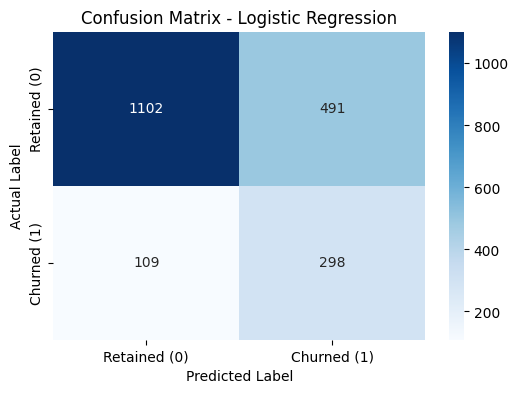

In [17]:
## 4. Predictive Modeling
### 4.1 Logistic Regression (Baseline)
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies.
log_reg = LogisticRegression(class_weight='balanced', random_state=42)

# 2. Train the Model (Using the scaled data from the previous step)
log_reg.fit(X_train_scaled, y_train)

# 3. Make Predictions on the Test Set
y_pred = log_reg.predict(X_test_scaled)

# 4. Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()
# if I do Logistic Regression, the accuracy ~ 70%, 
# high recall, this model successfully caught 70% of the 407 customers who actually churned
# low precision, Out of everyone your model predicted would churn, it was only right 39% of the time

In [18]:
### 4.2 Logistic Regression (by CV)
from sklearn.model_selection import GridSearchCV

#### Define the model (keeping the balanced weight for your imbalanced data)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#### Define the "Grid" of parameters

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100], # Controls regularization (smaller values = stronger penalty on complex models to prevent overfitting)
    'l1_ratio': [0, 1],  # 0 = L2 penalty, 1 = L1 penalty
    'solver': ['liblinear', 'saga'] # The algorithm used to find the best fit
}

#### Set up the GridSearchCV
#### cv=5 means 5-fold cross-validation
#### scoring='f1' ensures it finds the model that balances catching churners vs false alarms
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1, # Uses all your computer's processors to run faster
    verbose=1  # Prints text to show you it is actively working
)

#### Run the Search
grid_search.fit(X_train_scaled, y_train)

#### View the final results
print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", round(grid_search.best_score_, 3))

#### Extract the ultimate optimized model
best_log_reg_model = grid_search.best_estimator_


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters Found: {'C': 0.01, 'l1_ratio': 1, 'solver': 'liblinear'}
Best Cross-Validation F1-Score: 0.498


Optimized Accuracy: 0.7255

Optimized Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1593
           1       0.40      0.72      0.52       407

    accuracy                           0.73      2000
   macro avg       0.66      0.72      0.66      2000
weighted avg       0.81      0.73      0.75      2000



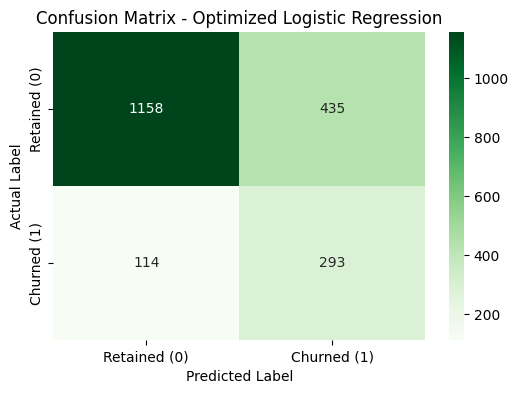

In [19]:
#### Print the new Evaluation Metrics
y_pred_optimized = best_log_reg_model.predict(X_test_scaled)
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_optimized))
print("\nOptimized Classification Report:\n", classification_report(y_test, y_pred_optimized))

#### Visualize the new Confusion Matrix
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Optimized Logistic Regression')
plt.show()
#### better than the base line model with accuracy ~ 73%

SVM Accuracy: 0.7915

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.49      0.75      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000



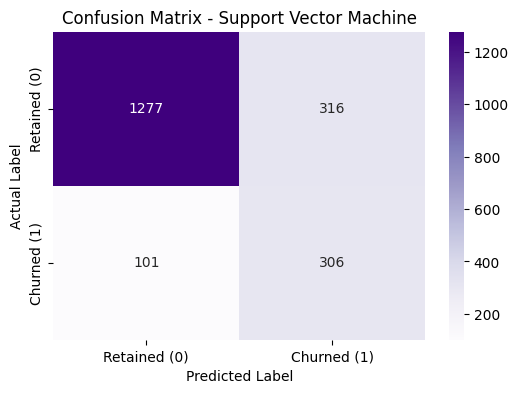

In [20]:
### 4.3 Support Vector Machine (SVM)
from sklearn.svm import SVC
#### Initialize the SVM Model
#### kernel='rbf' (Radial Basis Function) handles complex, non-linear patterns
#### class_weight='balanced' ensures it still pays heavy attention to your 21% churners
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

#### Train the Model 
#### Note: SVMs do a lot of heavy math, so this might take a few seconds longer than Logistic Regression!
svm_model.fit(X_train_scaled, y_train)

#### Make Predictions on the Test Set
y_pred_svm = svm_model.predict(X_test_scaled)

#### Evaluate the Model
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm)) # 0.78
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

##### Visualize the Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Support Vector Machine')
plt.show()
# better than Logistic Regression, accuracy ~ 80%

Starting SVM Grid Search... this may take a few minutes!
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best SVM Parameters: {'C': 100, 'gamma': 0.01}
SVM Accuracy: 0.7975

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86      1593
           1       0.50      0.76      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.73      2000
weighted avg       0.84      0.80      0.81      2000



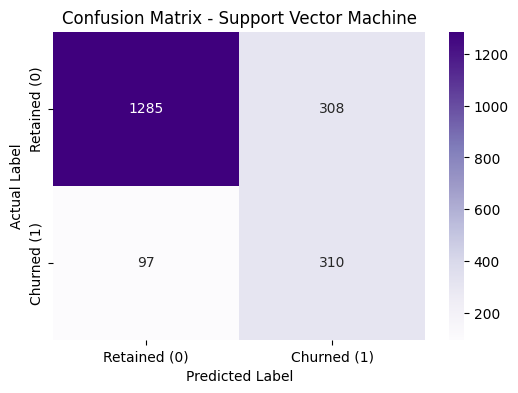

In [21]:
### 4.4 Support Vector Machine (SVM) by CV 
svm_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)

#### Define a targeted grid of parameters
param_grid_svm = {
    'C':[0.1, 1, 10,100], 
    'gamma': [0.1,0.01,0.001] 
}

#### Set up the Grid Search (Optimizing for F1-Score again)
grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1, # Uses all your CPU cores to speed up the math
    verbose=2  # verbose=2 gives you more frequent updates while it runs
)

#### Run the Search
print("Starting SVM Grid Search...")
grid_search_svm.fit(X_train_scaled, y_train)

#### Extract the results
print("\nBest SVM Parameters:", grid_search_svm.best_params_)
best_svm_model = grid_search_svm.best_estimator_
#### predict
y_pred_svm = best_svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

#### Visualize the Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Support Vector Machine')
plt.show()
#### not much improvement from SVM base so I decided go with SVM base

Random Forest Accuracy: 0.8055

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.83      0.87      1593
           1       0.52      0.71      0.60       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



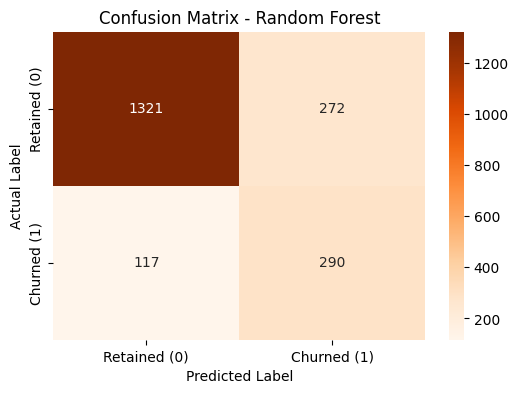

In [22]:
### 4.5 Random Forest Classifier (Optimized)
from sklearn.ensemble import RandomForestClassifier

#### n_estimators=100 means it will build 100 separate decision trees
#### max_depth=7 prevents the trees from growing too deep and memorizing the training data (overfitting)
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=7, 
    class_weight='balanced', 
    random_state=42
)

#### Train the Model 
rf_model.fit(X_train_scaled, y_train)

#### Make Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

#### Evaluate the Model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

#### Visualize the Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()
#### accuracy ~ 81% with high precision than other models

In [23]:
### 4.6 Random Forest Classifier (Optimized by CV)
from sklearn.model_selection import RandomizedSearchCV

#### 1. Initialize the base model
rf_base = RandomForestClassifier(random_state=42)

#### 2. Define the grid of parameters to randomly sample from
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 8, 12, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample']
}

#### 3. Set up the Randomized Search
# n_iter=50 means it will randomly test 50 different combinations
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=5,
    scoring='f1',
    n_jobs=-1, # Use all CPU cores
    random_state=42,
    verbose=2
)

#### 4. Run the Search
print("Starting Random Forest Tuning... this will test 50 combinations.")
random_search_rf.fit(X_train_scaled, y_train)

##### 5. Extract the best model
print("\nBest Random Forest Parameters:", random_search_rf.best_params_)
best_rf_model = random_search_rf.best_estimator_

Starting Random Forest Tuning... this will test 50 combinations.
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': 'balanced'}


              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.61      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.84      0.85      2000



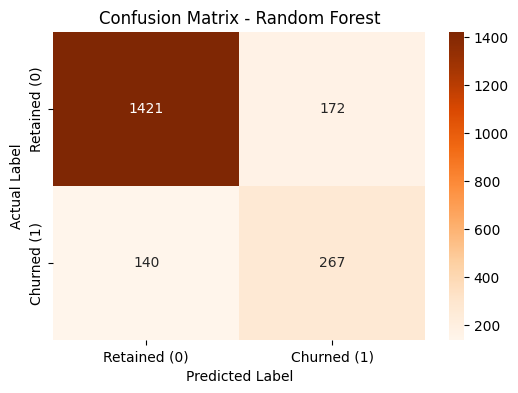

In [24]:
#### make prediction 
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf_tuned))

# Visualize the Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Random Forest')
plt.show()
#### accuracy = 84%

XGBoost Accuracy: 0.8375

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90      1593
           1       0.59      0.63      0.61       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



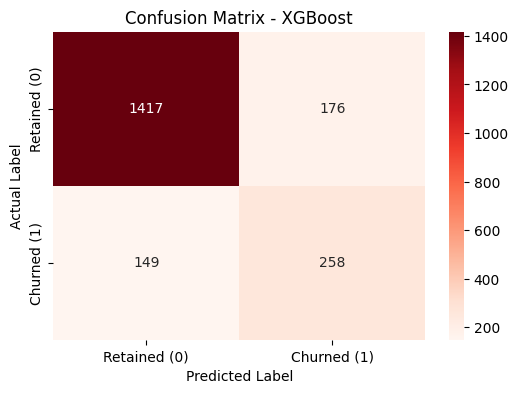

In [25]:
### 4.7 XGBoost
import xgboost as xgb
#### calculate the weigh
weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
#### Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=weight, 
    random_state=42,
    eval_metric='logloss' 
)

#### Train the Model
xgb_model.fit(X_train_scaled, y_train)
# Make Predictions on the Test Set
y_pred_xgb = xgb_model.predict(X_test_scaled)
#### Evaluate the Model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nXGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
#### isualize the Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - XGBoost')
plt.show()

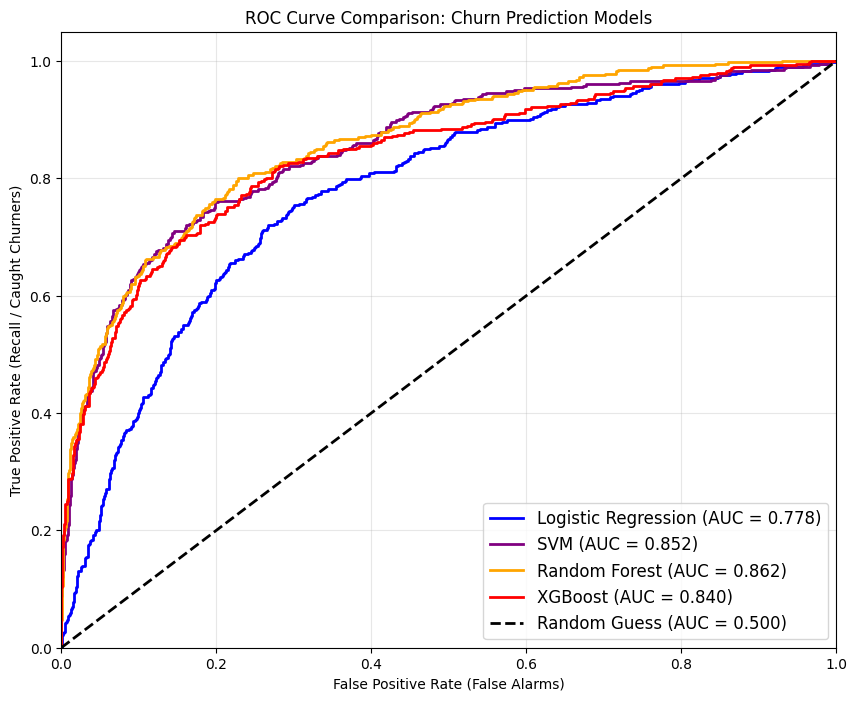

In [26]:
## 5. Model Evaluation
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
### Set up the plot size
plt.figure(figsize=(10, 8))

### Logistic Regression (Using the optimized GridSearch model)
y_prob_log = best_log_reg_model.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})', color='blue', linewidth=2)

### Support Vector Machine (Using decision_function)
y_score_svm = svm_model.decision_function(X_test_scaled)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', color='purple', linewidth=2)

### Random Forest 
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='orange', linewidth=2)

### XGBoost
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', color='red', linewidth=2)

#### Add the baseline diagonal line (A model that just flips a coin)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)', linewidth=2)

#### Format the plot nicely
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall / Caught Churners)')
plt.title('ROC Curve Comparison: Churn Prediction Models')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

#### Display the final graphic
plt.show()

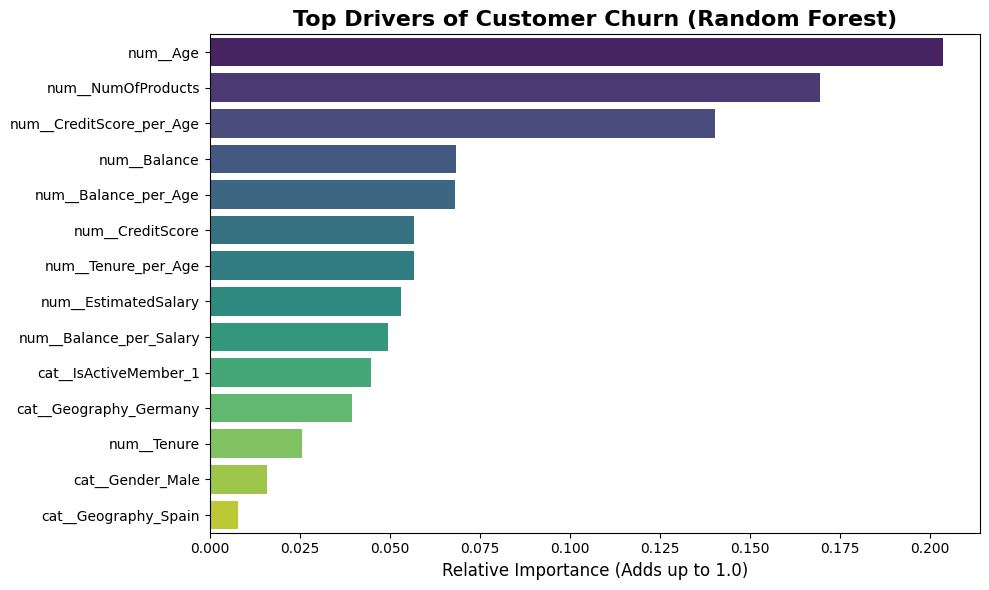

In [27]:
## 6. Business Insights & Interpretability
importances = best_rf_model.feature_importances_

# Grab the feature names
# (Make sure 'feature_names' is still saved in your environment from the ColumnTransformer step!)
feature_names = preprocessor.get_feature_names_out()

# 3. Create a clean DataFrame to pair the names with their scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort them from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the results using Seaborn
plt.figure(figsize=(10, 6)) # Make it wide enough to read the feature names
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis', # A professional, colorblind-friendly color palette
    hue='Feature',     # Required by newer versions of Seaborn when using palettes
    legend=False
)

# Add formatting and labels
plt.title('Top Drivers of Customer Churn (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Adds up to 1.0)', fontsize=12)
plt.ylabel('') # Leave the y-axis label blank for a cleaner look
plt.tight_layout() # Automatically adjusts margins so long feature names aren't cut off

# Display the chart
plt.show()

In [29]:
## 7. Data Export for BI Dashboard
### Grab the original index numbers from test set
test_indices = X_test.index
### Create a copy of original, UNSCALED test data
results_df = df.loc[test_indices].copy()

### Add the Model's final 1/0 Prediction
results_df['Predicted_Churn'] = best_rf_model.predict(X_test_scaled)

### Add the exact Probability Score (Risk percentage)
results_df['Churn_Risk_Percentage'] = best_rf_model.predict_proba(X_test_scaled)[:, 1]

### Export this final, rich dataset to a CSV
results_df.to_csv('bank_churn_predictions.csv', index=False)
print("Successfully exported to CSV for Power BI!")

Successfully exported to CSV for Power BI!
